In [ ]:
# 노트북 03 — 접근로별 최종 프로파일 통합
## 프로젝트 3: 차종 구성 프로파일링

**노트북 02에서 확인된 것 (전제)**
- k=4로 66개 관측치(접근로 11 × 시간대그룹 6)를 군집화함
- 군집 3(n=7)이 사실상 "새벽첫차(04-07) 시간대 그 자체"였음 — 이 시간대는 지점과 무관하게
  버스 효과가 워낙 강해서, 다른 성격(예: 물류)이 있어도 새벽첫차만큼은 전부 이 군집으로
  빨려 들어감
- 도메인 대조 중 발견: '농수산물센터'라는 이름과 달리, 실제 심야 트럭 비중은 11개 접근로 중
  **6위**에 불과함. 오히려 '오리공원', '까치마을사거리', '정자일로'가 더 높음 — 이름으로
  짐작하지 않고 실제 수치로 판단해야 한다는 원칙을 재확인한 사례

**이 노트북의 목적**
1. 새벽첫차를 별도 지표("버스 첫차 강도")로 분리하여, 시간대 효과와 지점 고유 성격을 나눔
2. 나머지 5개 시간대만으로 재군집화하여 지점 성격을 더 선명하게 추출
3. 이름이 아닌 실제 순위로 도메인 대조
4. 접근로 11개 각각의 최종 성격 프로파일을 하나의 표로 통합
5. 실행 가능한 의사결정 산출 (성능 수치가 아닌 결론으로 마무리)


## 0. 환경 설정 및 데이터 로드

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, adjusted_rand_score
from scipy.cluster.hierarchy import linkage, fcluster

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False
pd.set_option('display.width', 200)
pd.set_option('display.max_columns', 20)

BASE_DIR = Path('..')
PROCESSED_DIR = BASE_DIR / 'data' / 'processed'
FIG_DIR = BASE_DIR / 'outputs' / 'figures'
FIG_DIR.mkdir(parents=True, exist_ok=True)


In [2]:
pct = pd.read_csv(PROCESSED_DIR / '군집화_결과.csv')
BAND_ORDER = ['심야(00-04)', '새벽첫차(04-07)', '출근(07-10)', '낮(10-17)', '퇴근(17-20)', '저녁(20-24)']
pct['time_band'] = pd.Categorical(pct['time_band'], categories=BAND_ORDER, ordered=True)
feat_cols = ['승용차', '소형버스', '대형버스', '소형트럭', '대형트럭', '오토바이']

assert pct.shape[0] == 66
print('OK: 노트북 02 결과 66개 관측치 로드 확인')
pct[['AvenueName', 'time_band', 'cluster'] + feat_cols].head()


OK: 노트북 02 결과 66개 관측치 로드 확인


,AvenueName,time_band,cluster,승용차,소형버스,대형버스,소형트럭,대형트럭,오토바이
0,동막교사거리_경기고속삼거리방면,심야(00-04),2,88.645790,0.018112,2.086465,5.629109,0.981653,2.638871
1,동막교사거리_경기고속삼거리방면,새벽첫차(04-07),3,56.156032,1.255592,24.144502,13.913247,4.026775,0.503852
2,동막교사거리_경기고속삼거리방면,출근(07-10),0,79.322934,0.329228,7.493949,11.327489,1.076157,0.450242
3,동막교사거리_경기고속삼거리방면,낮(10-17),0,82.541045,0.215714,6.599564,7.025392,1.699161,1.919124
4,동막교사거리_경기고속삼거리방면,퇴근(17-20),2,89.845375,0.203968,4.465714,3.037329,0.762538,1.685075


## 1. 새벽첫차 분리 — "버스 첫차 강도" 지표

새벽첫차(04-07) 시간대는 노트북 02에서 확인했듯 지점과 무관하게 버스 효과가 지배적입니다.
이걸 군집화 피처에 그대로 두면 지점 고유 성격이 가려지므로, 별도의 스칼라 지표로 분리합니다.
값이 클수록 그 접근로는 새벽 버스 노선의 영향을 강하게 받는다는 뜻입니다.

=== 접근로별 새벽첫차 버스 강도 순위 ===


,AvenueName,버스강도,순위
0,동막교사거리_오리역방면,27.708154,1
1,동막교사거리_경기고속삼거리방면,25.400094,2
2,미금역사거리_청송마을사거리방면,24.346071,3
3,미금역사거리_미금역방면,21.551242,4
4,오리삼거리_오리역방면,21.189311,5
5,오리삼거리_농수산물센터방면,16.264892,6
6,동막교사거리_동막교삼거리방면,16.028109,7
7,오리삼거리_오리교1사거리방면,11.228953,8
8,미금역사거리_정자일로방면,10.525269,9
9,미금역사거리_까치마을사거리방면,7.821658,10


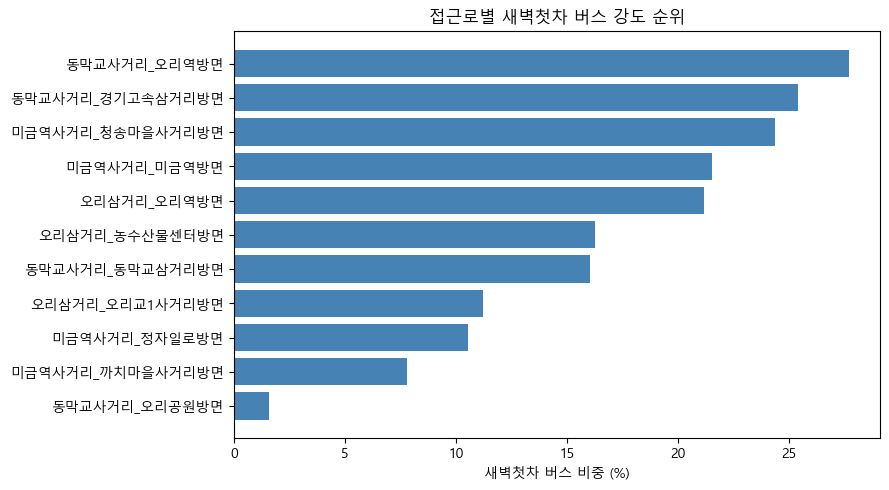

In [3]:
dawn = pct[pct['time_band'] == '새벽첫차(04-07)'].copy()
dawn['버스강도'] = dawn['소형버스'] + dawn['대형버스']
dawn_rank = dawn[['AvenueName', '버스강도']].sort_values('버스강도', ascending=False).reset_index(drop=True)
dawn_rank['순위'] = dawn_rank.index + 1

print('=== 접근로별 새벽첫차 버스 강도 순위 ===')
display(dawn_rank)

fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(dawn_rank['AvenueName'][::-1], dawn_rank['버스강도'][::-1], color='steelblue')
ax.set_xlabel('새벽첫차 버스 비중 (%)')
ax.set_title('접근로별 새벽첫차 버스 강도 순위')
plt.tight_layout()
plt.savefig(FIG_DIR / 'nb03_버스강도_순위.png', dpi=150)
plt.show()


## 2. 새벽첫차 제외 후 재군집화 — k 재검증

새벽첫차를 뺀 55개 관측치(11 × 5)로 노트북 02와 같은 방식(실루엣 + 부트스트랩 안정성)의
진단을 다시 합니다. 짐작으로 같은 k를 재사용하지 않고, 다시 확인합니다.

In [4]:
rest = pct[pct['time_band'] != '새벽첫차(04-07)'].copy()
assert rest.shape[0] == 55, f'예상과 다릅니다: {rest.shape[0]} (기대값 11x5=55)'
print('OK: 55개 관측치 확인')

X = StandardScaler().fit_transform(rest[feat_cols].values)

def bootstrap_stability(X, k, n_boot=30, seed=0):
    rng = np.random.RandomState(seed)
    n = X.shape[0]
    km_full = KMeans(n_clusters=k, n_init=20, random_state=42).fit(X)
    aris = []
    for b in range(n_boot):
        idx = rng.choice(n, size=n, replace=True)
        km_b = KMeans(n_clusters=k, n_init=10, random_state=b).fit(X[idx])
        aris.append(adjusted_rand_score(km_full.labels_, km_b.predict(X)))
    return km_full, np.mean(aris)

results = []
for k in range(2, 8):
    km_full, stability = bootstrap_stability(X, k)
    sil = silhouette_score(X, km_full.labels_)
    sizes = np.bincount(km_full.labels_)
    results.append({'k': k, 'silhouette': round(sil, 3), '부트스트랩_안정성(ARI)': round(stability, 3),
                     '최소_군집크기': sizes.min(), '군집크기_전체': list(sizes)})

result_df2 = pd.DataFrame(results)
result_df2


OK: 55개 관측치 확인


C:\Users\chpar\anaconda3\envs\TDFP\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] 지정된 파일을 찾을 수 없습니다
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "C:\Users\chpar\anaconda3\envs\TDFP\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "C:\Users\chpar\anaconda3\envs\TDFP\Lib\subprocess.py", line 550, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\chpar\anaconda3\envs\TDFP\Lib\subprocess.py", line 1028, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "C:\Users\chpar\anaconda3\envs\TDFP\Lib\subprocess.py", line 1540, in _execute_child
    hp, ht, pi

,k,silhouette,부트스트랩_안정성(ARI),최소_군집크기,군집크기_전체
0,2,0.220,0.453,24,"[31, 24]"
1,3,0.249,0.576,5,"[5, 26, 24]"
2,4,0.230,0.568,5,"[16, 17, 17, 5]"
3,5,0.233,0.468,5,"[5, 16, 11, 5, 18]"
4,6,0.221,0.472,3,"[10, 9, 14, 15, 3, 4]"
5,7,0.240,0.499,4,"[4, 13, 8, 11, 6, 9, 4]"


**해석**: 노트북 02에서는 k=5 이상에서 1개짜리 군집(불안정)이 나왔습니다. 새벽첫차를 뺀
지금 결과에서 그런 불안정한 k가 있는지 확인하세요. 아래 CANDIDATE_K를 위 표를 보고 정하세요
(기본값 4).

In [5]:
CANDIDATE_K = 4

km_final = KMeans(n_clusters=CANDIDATE_K, n_init=20, random_state=42).fit(X)
rest['cluster'] = km_final.labels_

Z = linkage(X, method='ward')
hier_labels = fcluster(Z, CANDIDATE_K, criterion='maxclust')
ari_cross = adjusted_rand_score(km_final.labels_, hier_labels)

print(f'k={CANDIDATE_K} 선택, K-means vs 계층적 군집화 일치도(ARI): {ari_cross:.3f}')
print(f'군집별 관측치 수: {np.bincount(km_final.labels_)}')


k=4 선택, K-means vs 계층적 군집화 일치도(ARI): 0.497
군집별 관측치 수: [16 17 17  5]


C:\Users\chpar\anaconda3\envs\TDFP\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


## 3. 재군집화 프로파일 해석

,승용차,소형버스,대형버스,소형트럭,대형트럭,오토바이,n_관측치
cluster,,,,,,,
0,86.93,1.19,7.50,3.06,0.50,0.82,16
1,81.15,0.71,12.63,2.82,0.49,2.20,17
2,89.61,0.38,3.87,3.67,0.75,1.73,17
3,82.63,0.22,3.87,10.48,1.18,1.62,5


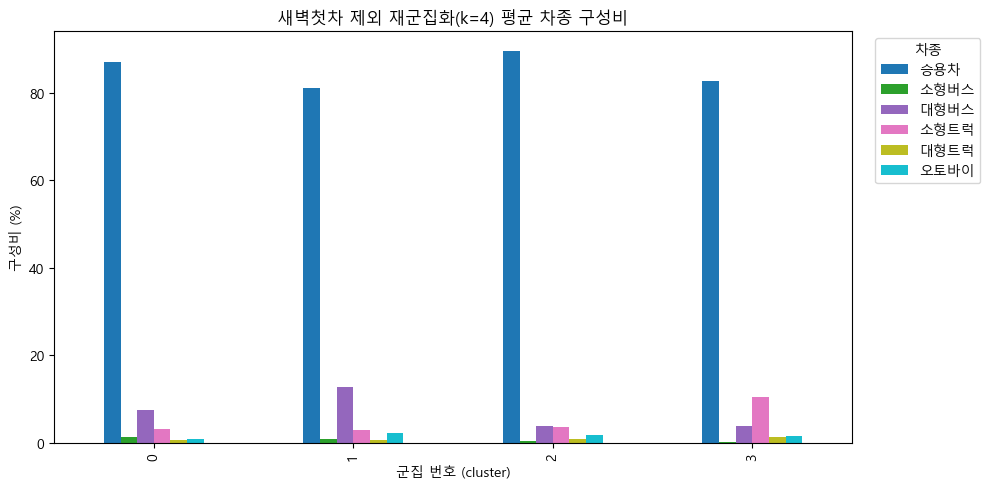

In [6]:
profile2 = rest.groupby('cluster')[feat_cols].mean().round(2)
profile2['n_관측치'] = rest['cluster'].value_counts().sort_index()
display(profile2)

fig, ax = plt.subplots(figsize=(10, 5))
profile2[feat_cols].plot(kind='bar', ax=ax, colormap='tab10')
ax.set_title(f'새벽첫차 제외 재군집화(k={CANDIDATE_K}) 평균 차종 구성비')
ax.set_xlabel('군집 번호 (cluster)')
ax.set_ylabel('구성비 (%)')
ax.legend(title='차종', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.savefig(FIG_DIR / 'nb03_재군집_프로파일.png', dpi=150)
plt.show()


**이름 붙이기**: 위 표를 보고 아래 딕셔너리를 채우세요. (노트북 02의 cluster_names와는
별개입니다 — 새벽첫차를 뺐으니 군집 번호와 성격이 달라질 수 있습니다.)

In [13]:
rest_cluster_names = {
    0: '일반형(승용차 중심, 버스 소폭 포함)',
    1: '대중교통·배달 혼합형(버스·오토바이 비중 높음)',
    2: '순수 일반/주거 접근형(모든 특수차종 비중 낮음)',
    3: '물류(화물) 특화형 - 국지적(주로 심야 시간대에 집중)',
}
rest['cluster_name'] = rest['cluster'].map(rest_cluster_names)


## 4. 도메인 대조 — 이름이 아니라 실제 순위로 판단

노트북 02에서 배운 교훈: 접근로 이름(예: '농수산물센터')만 보고 성격을 짐작하면 안 됩니다.
아래에서 트럭 비중, 버스 비중 각각 실제 순위를 뽑아서, 어떤 접근로가 진짜 물류/대중교통
성격에 가까운지 데이터로 확인합니다.

In [14]:
rest['트럭계'] = rest['소형트럭'] + rest['대형트럭']
rest['버스계'] = rest['소형버스'] + rest['대형버스']

avg_by_avenue = rest.groupby('AvenueName')[['트럭계', '버스계', '오토바이']].mean().round(2)

print('=== 접근로별 평균 트럭 비중 순위 (새벽첫차 제외) ===')
display(avg_by_avenue.sort_values('트럭계', ascending=False))

print('\n=== 접근로별 평균 버스 비중 순위 (새벽첫차 제외) ===')
display(avg_by_avenue.sort_values('버스계', ascending=False))

print('\n=== 접근로별 평균 오토바이 비중 순위 ===')
display(avg_by_avenue.sort_values('오토바이', ascending=False))


=== 접근로별 평균 트럭 비중 순위 (새벽첫차 제외) ===


,트럭계,버스계,오토바이
AvenueName,,,
동막교사거리_오리공원방면,6.91,1.08,1.38
동막교사거리_경기고속삼거리방면,6.85,5.93,1.66
미금역사거리_정자일로방면,4.77,5.62,1.31
미금역사거리_까치마을사거리방면,4.65,5.54,1.01
동막교사거리_동막교삼거리방면,4.56,10.80,1.97
오리삼거리_오리교1사거리방면,4.14,9.27,1.45
오리삼거리_오리역방면,4.14,8.61,1.05
오리삼거리_농수산물센터방면,3.68,8.99,0.86
미금역사거리_미금역방면,3.54,10.73,2.15



=== 접근로별 평균 버스 비중 순위 (새벽첫차 제외) ===


,트럭계,버스계,오토바이
AvenueName,,,
미금역사거리_청송마을사거리방면,3.25,13.24,1.86
동막교사거리_오리역방면,2.84,11.91,2.88
동막교사거리_동막교삼거리방면,4.56,10.80,1.97
미금역사거리_미금역방면,3.54,10.73,2.15
오리삼거리_오리교1사거리방면,4.14,9.27,1.45
오리삼거리_농수산물센터방면,3.68,8.99,0.86
오리삼거리_오리역방면,4.14,8.61,1.05
동막교사거리_경기고속삼거리방면,6.85,5.93,1.66
미금역사거리_정자일로방면,4.77,5.62,1.31



=== 접근로별 평균 오토바이 비중 순위 ===


,트럭계,버스계,오토바이
AvenueName,,,
동막교사거리_오리역방면,2.84,11.91,2.88
미금역사거리_미금역방면,3.54,10.73,2.15
동막교사거리_동막교삼거리방면,4.56,10.80,1.97
미금역사거리_청송마을사거리방면,3.25,13.24,1.86
동막교사거리_경기고속삼거리방면,6.85,5.93,1.66
오리삼거리_오리교1사거리방면,4.14,9.27,1.45
동막교사거리_오리공원방면,6.91,1.08,1.38
미금역사거리_정자일로방면,4.77,5.62,1.31
오리삼거리_오리역방면,4.14,8.61,1.05


이 세 순위표가 이름에 대한 통념과 다를 수 있습니다. 다르다면 그게 진짜 발견입니다 —
'농수산물센터라서 물류축'이 아니라, '실제로 트럭 비중이 몇 위인 접근로가 물류 성격을 갖는다'는
식으로 결론을 내려야 합니다.

## 5. 접근로별 최종 통합 프로파일

각 접근로에 대해:
- 새벽첫차 버스 강도(순위)
- 나머지 5개 시간대 기준 주된 군집(성격)
- 트럭/버스/오토바이 순위

를 하나의 표로 합쳐서 최종 프로파일을 만듭니다.

In [15]:
dominant_cluster = rest.groupby('AvenueName')['cluster'].agg(lambda s: s.value_counts().idxmax())
dominant_name = dominant_cluster.map(rest_cluster_names)

final_profile = pd.DataFrame({
    '새벽첫차_버스강도': dawn.set_index('AvenueName')['버스강도'],
    '새벽첫차_순위': dawn_rank.set_index('AvenueName')['순위'],
    '주된_군집(새벽첫차제외)': dominant_cluster,
    '주된_성격': dominant_name,
    '트럭비중_순위': avg_by_avenue['트럭계'].rank(ascending=False).astype(int),
    '버스비중_순위': avg_by_avenue['버스계'].rank(ascending=False).astype(int),
    '오토바이비중_순위': avg_by_avenue['오토바이'].rank(ascending=False).astype(int),
})
final_profile = final_profile.sort_values('새벽첫차_순위')
final_profile


,새벽첫차_버스강도,새벽첫차_순위,주된_군집(새벽첫차제외),주된_성격,트럭비중_순위,버스비중_순위,오토바이비중_순위
AvenueName,,,,,,,
동막교사거리_오리역방면,27.708154,1,1,대중교통·배달 혼합형(버스·오토바이 비중 높음),11,2,1
동막교사거리_경기고속삼거리방면,25.400094,2,2,순수 일반/주거 접근형(모든 특수차종 비중 낮음),2,8,5
미금역사거리_청송마을사거리방면,24.346071,3,1,대중교통·배달 혼합형(버스·오토바이 비중 높음),10,1,4
미금역사거리_미금역방면,21.551242,4,1,대중교통·배달 혼합형(버스·오토바이 비중 높음),9,4,2
오리삼거리_오리역방면,21.189311,5,0,"일반형(승용차 중심, 버스 소폭 포함)",6,7,9
오리삼거리_농수산물센터방면,16.264892,6,0,"일반형(승용차 중심, 버스 소폭 포함)",8,6,11
동막교사거리_동막교삼거리방면,16.028109,7,1,대중교통·배달 혼합형(버스·오토바이 비중 높음),5,3,3
오리삼거리_오리교1사거리방면,11.228953,8,2,순수 일반/주거 접근형(모든 특수차종 비중 낮음),6,5,6
미금역사거리_정자일로방면,10.525269,9,0,"일반형(승용차 중심, 버스 소폭 포함)",3,9,8


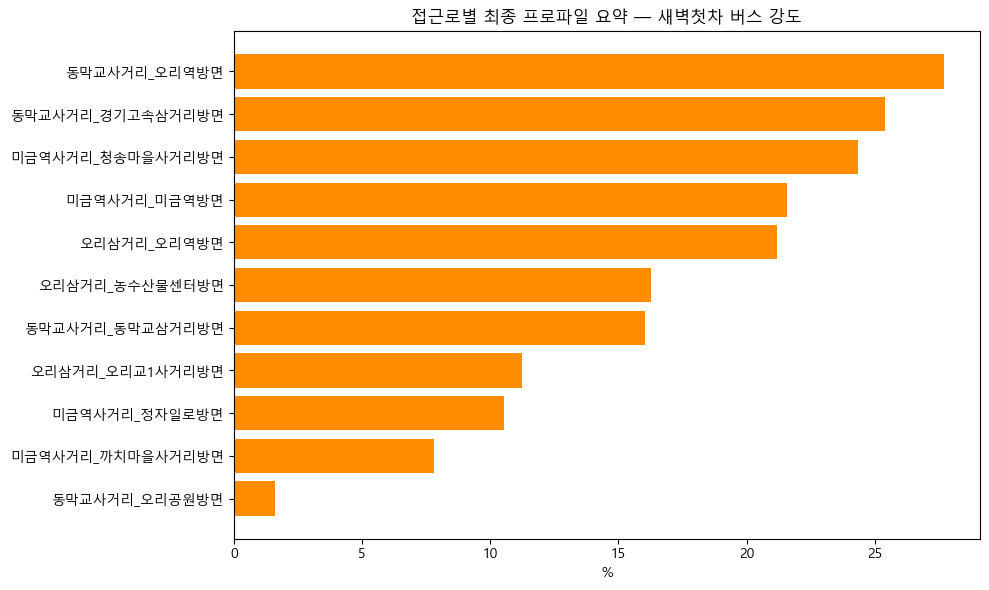

In [16]:
fig, ax = plt.subplots(figsize=(10, 6))
order = final_profile.index
ax.barh(order[::-1], final_profile['새벽첫차_버스강도'][::-1], color='darkorange', label='새벽첫차 버스강도(%)')
ax.set_xlabel('%')
ax.set_title('접근로별 최종 프로파일 요약 — 새벽첫차 버스 강도')
plt.tight_layout()
plt.savefig(FIG_DIR / 'nb03_최종프로파일_요약.png', dpi=150)
plt.show()


## 6. 결과 저장

In [17]:
rest.to_csv(PROCESSED_DIR / '재군집화_결과(새벽첫차제외).csv', index=False, encoding='utf-8-sig')
final_profile.to_csv(PROCESSED_DIR / '접근로별_최종프로파일.csv', encoding='utf-8-sig')

print('저장 완료:')
print(f'  {PROCESSED_DIR / "재군집화_결과(새벽첫차제외).csv"}')
print(f'  {PROCESSED_DIR / "접근로별_최종프로파일.csv"}')


저장 완료:
  ..\data\processed\재군집화_결과(새벽첫차제외).csv
  ..\data\processed\접근로별_최종프로파일.csv


## 7. 의사결정 산출

프로젝트 원칙: 결론은 성능 수치가 아니라 실행 가능한 의사결정으로 낸다. `final_profile`
표를 직접 보고 아래 형식으로 3~5개 문장을 정리하세요 (예시):

- "새벽첫차 버스 강도 상위 3개 접근로(OOO, OOO, OOO)는 첫차 시간대 전용 버스 우선 신호를
  검토할 우선순위 대상이다."
- "트럭 비중 순위 상위 접근로가 이름과 무관하게 실제 물류축 성격을 가지므로, 화물차 통행
  데이터 기반 도로 보수/설계 우선순위에 이 순위를 반영해야 한다."
- "오토바이 비중이 높은 접근로는 배달 수요가 많은 곳으로, 배달 오토바이 사고 예방 대책의
  우선 배치 후보다."

이 문장들이 포트폴리오 보고서의 핵심 결론이 됩니다. 다음 단계에서 이걸 반영해 최종
분석 보고서(Word) 및 GitHub 정리로 넘어갑니다.


1. 새벽첫차 버스강도 상위 3개 접근로(동막교사거리_오리역방면 27.7%, 동막교사거리_경기고속삼거리방면 25.4%, 미금역사거리_청송마을사거리방면 24.3%)는 노선버스 첫차 우선신호 등 대중교통 우선 정책의 최우선 검토 대상이다.
2. 심야 트럭 비중이 실제로 가장 높은 곳은 이름상 물류 거점으로 알려진 **농수산물센터(트럭 순위 8위)가 아니라 오리공원(1위)·경기고속삼거리(2위)**이므로, 화물차 관련 도로 정비·단속 우선순위는 명칭이 아니라 실측 데이터로 재조정해야 한다.
3. 오리공원 접근로는 하루 대부분 일반적인 승용차 흐름을 보이다가 심야에만 트럭 비중이 급증하는 국지적 패턴을 보이므로, 24시간 일괄 대책보다 심야 시간대 한정 화물차 대책(전용 신호, 소음 관리)이 더 적합하다.
4. **오토바이(배달) 비중이 가장 높은 접근로는 동막교사거리_오리역방면(2.9%)과 미금역사거리_미금역방면(2.2%)**로, 두 곳 모두 대중교통·배달 혼합형 군집에 속해 있어 배달 이륜차 안전대책의 우선 배치 후보다.
5. 농수산물센터방면은 이름과 달리 트럭·버스 어느 지표로도 상위권이 아닌 평이한 접근로로 확인됐다 — 이번 분석의 핵심 시사점은 "명칭 기반 통념이 아니라 실측 차종 구성 데이터로 정책 우선순위를 정해야 한다"는 것이다.